In [3]:
import os 
import sys 
import pandas as pd
import json 
import cv2
sys.path.append("/home/abharadwaj1/thesis/5_vitrification/utils")
sys.path.append("/home/abharadwaj1/thesis/utils")
from video_utils import get_specific_frame, detect_surface_level, get_line_intensities, detect_time_of_grid_arrival_from_kymograph
from plot_utils import configure_plot_scaling, temporary_rcparams
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import IntSlider, FloatSlider, VBox, HBox, Output, interact, Checkbox, SelectionRangeSlider
from IPython.display import display, clear_output

In [4]:
# Function definitions
# Detect edges of the kymograph to measure the air gap thickness 
def detect_edge_from_kymograph(kymograph):
    """
    Detect the edges of the kymograph based on a Canny edge detection algorithm.
    """
    import cv2
    from scipy.ndimage import uniform_filter

    # Convert kymograph to grayscale if it is not already
    if len(kymograph.shape) == 3:
        kymograph_gray = cv2.cvtColor(kymograph, cv2.COLOR_BGR2GRAY)
    else:
        kymograph_gray = kymograph
    
    kymograph_filtered = uniform_filter(kymograph_gray, size=(6, 6), mode='nearest')
    kymograph_normalised = (kymograph_filtered - kymograph_filtered.min()) / (kymograph_filtered.max() - kymograph_filtered.min())
    kymograph_binarised = (kymograph_normalised < 0.5).astype(np.uint8)  # Binarise the kymograph
    # Apply Canny edge detection

    edges = cv2.Canny(kymograph_binarised, 0.2, 0.8)
    # return normalised values for edges 
    edges_normalised = edges / edges.max()
    edges_binarised = (edges_normalised > 0.5).astype(int)  # Binarise the edges
    return edges_binarised
def cluster_points_using_dbscale(x_points, y_points, eps=3, min_samples=2):
    from sklearn.cluster import DBSCAN
    dbscan = DBSCAN(eps=eps, min_samples=min_samples, metric='euclidean')
    edge_points = np.column_stack((x_points, y_points))
    dbscan.fit(edge_points)
    labels = dbscan.labels_
    # Get unique labels
    unique_labels = set(labels)
    # Create a dictionary to store the points for each label
    edge_clusters = {}
    for label in unique_labels:
        if label == -1:  # -1 is the noise label
            continue
        indices = np.where(labels == label)[0]
        edge_clusters[label] = edge_points[indices]

    largest_cluster_label = max(edge_clusters, key=lambda k: len(edge_clusters[k]))
    edge_points_largest_cluster = edge_clusters[largest_cluster_label]
    return edge_points_largest_cluster
def get_velocity_from_kymograph(kymograph, time_points_for_each_depth, apix, sampling_time, epsilon=3, min_points=2):

    # Step 1: Create a mask for detection area
    detection_area_mask = np.zeros_like(kymograph)
    start_time = time_points_for_each_depth["start_time"]
    end_time = time_points_for_each_depth["end_time"]
    y_top_pix = time_points_for_each_depth["y_top_pix"]
    y_bottom_pix = time_points_for_each_depth["y_bottom_pix"]
    detection_area_mask[y_top_pix:y_bottom_pix, start_time:end_time] = 1

    # Step 2: Detect edges in the kymograph
    edges = detect_edge_from_kymograph(kymograph)
    edges_y, edges_x = np.where(edges == 1)

    # Step 3: Find the points in the largest cluster
    edge_points_largest_cluster = cluster_points_using_dbscale(edges_x, edges_y, eps=epsilon, min_samples=min_points)
    x_points_largest_cluster = edge_points_largest_cluster[:, 0]
    y_points_largest_cluster = edge_points_largest_cluster[:, 1]
    # Step 4: Filter based on detection area mask
    y_mask, x_mask = np.where(detection_area_mask == 1)
    set_of_points_in_mask = set(zip(x_mask, y_mask))
    set_of_edge_points = set(zip(edge_points_largest_cluster[:, 0], edge_points_largest_cluster[:, 1]))
    
    set_of_points_in_mask_and_edges = set_of_points_in_mask.intersection(set_of_edge_points) 
    
    # if set_of_points_in_mask_and_edges is empty, return nan 
    if not set_of_points_in_mask_and_edges:
        print("No points found in the mask and edges intersection.")
        return {
            "velocity_pixel_per_frame": np.nan,
            "velocity_m_per_s": np.nan,
            "x_fit": [],
            "y_fit": [],
            "x_points_filtered": [],
            "y_points_filtered": [],
            "r2_fit": 0,
        }
    
    x_points_filtered, y_points_filtered = zip(*set_of_points_in_mask_and_edges) if set_of_points_in_mask_and_edges else ([], [])

    # Step 5: Calculate the velocity
    velocity_pixel_per_frame, intercept = np.polyfit(x_points_filtered, y_points_filtered, 1)
    velocity_pixel_per_frame = velocity_pixel_per_frame  
    velocity_m_per_s = -1 * velocity_pixel_per_frame * apix / sampling_time  # convert to m/s

    x_fit = np.array(x_points_filtered)
    y_fit = velocity_pixel_per_frame * x_fit + intercept

    ss_res = np.sum((y_points_filtered - y_fit) ** 2)
    ss_tot = np.sum((y_points_filtered - np.mean(y_points_filtered)) ** 2)
    r2_fit = 1 - (ss_res / ss_tot) if ss_tot != 0 else np.nan


    velocity_result = {
        "velocity_pixel_per_frame": velocity_pixel_per_frame,
        "velocity_m_per_s": velocity_m_per_s,
        "x_fit": x_fit,
        "y_fit": y_fit,
        "x_points_filtered": x_points_filtered,
        "y_points_filtered": y_points_filtered,
        "r2_fit": r2_fit,
    }
    return velocity_result


def show_kymograph_start_end(frame_start, frame_end, frame_start_num, frame_end_num, surface_level, y_1, y_2):
    fig, ax = plt.subplots(1, 2, figsize=(12, 6))
    ax[0].imshow(frame_start, cmap='gray')
    ax[0].axvline(surface_level, color='red', linestyle='--', label='Surface Level')
    #ax.axvline(kymograph_depth_pixels, color='green', linestyle='--', label='Kymograph Depth')
    ax[0].set_title(f"Start frame {frame_start_num}")
    sample_line_depth_pix = surface_level + 100
    ax[0].plot([sample_line_depth_pix, sample_line_depth_pix], [y_1, y_2], color='blue', linestyle='--', label='Sample Line Depth')
    ax[0].legend()
    ax[1].imshow(frame_end, cmap='gray')
    ax[1].set_title(f"End frame {frame_end_num}")
    ax[1].axvline(surface_level, color='red', linestyle='--', label='Surface Level')
    ax[1].plot([sample_line_depth_pix, sample_line_depth_pix], [y_1, y_2], color='blue', linestyle='--', label='Sample Line Depth')
    ax[1].legend()
    fig.tight_layout()
    fig.show()


In [5]:
#video_path = "/home/abharadwaj1/thesis/data_archive/inputs/5_vitrification/measure_air_gap_for_substrates/si_old_chip/oldSiChip_front_vid_2025-07-21_18-43-57.mp4"
#video_path = "/home/abharadwaj1/thesis/data_archive/inputs/5_vitrification/measure_air_gap_for_substrates/autogrid/autogrid_front_vid_2025-07-21_19-28-45.mp4"
#video_path = "/home/abharadwaj1/thesis/data_archive/inputs/5_vitrification/measure_air_gap_for_substrates/si_old_chip/oldSiChip_side_vid_2025-07-21_18-39-26.mp4"
#video_path = "/home/abharadwaj1/thesis/data_archive/inputs/5_vitrification/measure_air_gap_for_substrates/autogrid/autogrid_side_vid_2025-07-21_19-25-39.mp4"

#video_path = "/home/abharadwaj1/thesis/data_archive/inputs/5_vitrification/thickness_analysis/thickness_100/vid_2025-08-01_17-37-08.mp4"
video_path = "/home/abharadwaj1/thesis/data_archive/inputs/5_vitrification/cavity_closing_trials/autogrid_front/vid_2024-08-29_18-08-00.mp4"
print(f"Processing video: {os.path.basename(video_path)}")
assert os.path.exists(video_path), f"Video file {video_path} does not exist."

Processing video: vid_2024-08-29_18-08-00.mp4


In [6]:
# Use interactivity to select calibration frames and parameters 
max_number_of_frames = cv2.VideoCapture(video_path).get(cv2.CAP_PROP_FRAME_COUNT)
frame_1 = get_specific_frame(video_path, 0)
height, width = frame_1.shape[:2]
# Create sliders for user input
use_manual_apix = Checkbox(description = "Use Manual Pixel Size?", value=False)
display(use_manual_apix)

Checkbox(value=False, description='Use Manual Pixel Size?')

In [7]:
# define apix_value as global variable
global apix_value;
apix_value = 20e-6

if use_manual_apix.value:
    apix_value_slider = FloatSlider(value=apix_value*1e6, min=1, max=100, step=0.00001, description='Pixel Size (um/pix):')
    display(apix_value_slider)
else:
    # Choose calibration frames and mark two points with reference length 
    cap = cv2.VideoCapture(video_path)
    # Load the calibration frame
    def get_calibration_frame(frame_num):
        cap.set(cv2.CAP_PROP_POS_FRAMES, frame_num)
        ret, frame = cap.read()
        if not ret:
            raise ValueError("Could not read frame")
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        return gray

    output1 = Output()

    def update_calibration_plot(frame_num, p1, p2, distance_mm):
        apix_value = distance_mm * 1e-3 / abs(p2 - p1)  # Calculate pixel size in um/pix

        with output1:
            clear_output(wait=True)
            frame = get_calibration_frame(frame_num)
            plt.figure(figsize=(10, 5))
            plt.imshow(frame, cmap='gray')
            plt.axhline(p1, color='red', linestyle='--', label='Point 1')
            plt.axhline(p2, color='blue', linestyle='--', label='Point 2')
            plt.title(f"Calibration Frame {frame_num}\nPixel size = {apix_value*1e6:.2f} um/pixel")
            plt.legend()
            plt.show()
        
    max_num_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    shape_frame = get_calibration_frame(0).shape
    frame_slider = IntSlider(value=0, min=0, max=max_num_frames, description="Frame")
    p1_slider = IntSlider(value=0, min=0, max=shape_frame[1], description="Point 1")
    p2_slider = IntSlider(value=shape_frame[1], min=0, max=shape_frame[0], description="Point 2")
    dist_slider = FloatSlider(value=3.538, min=0.1, max=10.0, step=0.01, description="Ref (mm)")
    #apix_value = dist_slider.value * 1e-3 / abs(p2_slider.value - p1_slider.value)  # Calculate pixel size in um/pix
    interact(update_calibration_plot,
            frame_num=frame_slider,
            p1=p1_slider,
            p2=p2_slider,
            distance_mm=dist_slider)
    display(output1)

FloatSlider(value=20.0, description='Pixel Size (um/pix):', min=1.0, step=1e-05)

In [8]:
apix = apix_value_slider.value * 1e-6 if use_manual_apix.value else dist_slider.value * 1e-3 / abs(p2_slider.value - p1_slider.value)  # Convert to meters
frame_rate = 5406 
sampling_time = 1 / frame_rate  # in seconds
vplunge = 1 # Plunge velocity in m/s
print(f"Pixel size: {apix * 1e6:.2f} um/pixel")
print(f"Sampling time: {sampling_time*1e6:.2f} us")
print(f"Plunge velocity: {vplunge:.2f} m/s")
grid_shift_per_frame = vplunge * sampling_time / apix  # in pixels per frame 
#print(f"Grid shift per frame: {grid_shift_per_frame:.2f} pixels/frame")
grid_frames_per_pixel_shift = 1 / grid_shift_per_frame  # in frames per pixel shift
print(f"Grid takes {grid_frames_per_pixel_shift:.2f} frames to shift by 1 pixel")

Pixel size: 16.70 um/pixel
Sampling time: 184.98 us
Plunge velocity: 1.00 m/s
Grid takes 0.09 frames to shift by 1 pixel


In [9]:
# Step 2: Detect surface level and start and end frames
start_frame_for_extraction = IntSlider(value=0, min=0, max=int(max_number_of_frames - 50), description="Start Frame")
length_of_frames = IntSlider(value=100, min=10, max=200, description="Length of Frames")
y_1_slider = IntSlider(value=75, min=0, max=height, description="Y1")
y_2_slider = IntSlider(value=75+275, min=0, max=height, description="Y2")
min_depth_slider = FloatSlider(value=0.25, min=0.1, max=7.5, step=0.05, description="Min Depth (mm)")
max_depth_slider = FloatSlider(value=7.5, min=0.1, max=7.5, step=0.05, description="Max Depth (mm)")
output2 = Output()
def update_start_end_frames(start_frame_num, length_of_frames, y_1, y_2, min_depth=0.25, max_depth=7.5):
    depths_to_extract = np.arange(min_depth, max_depth+0.05, 0.05)  # in mm, adjust as needed

    with output2:
        clear_output(wait=True)
        start_frame = get_specific_frame(video_path, start_frame_num)
        end_frame = get_specific_frame(video_path, start_frame_num + length_of_frames)
        surface_level = detect_surface_level(start_frame)[0]
        depths_to_extract_pix = [surface_level + int(depth / apix) for depth in depths_to_extract * 1e-3]  # convert to pixels
        mask_depth = np.zeros_like(start_frame, dtype=int)
        mask_depth[y_1:y_2, depths_to_extract_pix[0]:depths_to_extract_pix[-1]] = 1

        plt.subplot(121)
        plt.imshow(start_frame, cmap='gray')
        plt.imshow(mask_depth, cmap='jet', alpha=0.5, vmin=0, vmax=1)
        #plt.axhline(y_1, color='red', linestyle='--', label='Y1')
        #plt.axhline(y_2, color='blue', linestyle='--', label='Y2')
        plt.axvline(surface_level, color='green', linestyle='--', label='Surface Level')
        plt.title(f"Start frame {start_frame_num}")
        #plt.legend()
        plt.subplot(122)
        plt.imshow(end_frame, cmap='gray')
        plt.imshow(mask_depth, cmap='jet', alpha=0.5, vmin=0, vmax=1)
        #plt.axhline(y_1, color='red', linestyle='--', label='Y1')
        #plt.axhline(y_2, color='blue', linestyle='--', label='Y2')
        plt.axvline(surface_level, color='green', linestyle='--', label='Surface Level')
        plt.title(f"End frame {start_frame_num + length_of_frames}")
        #plt.legend()
        plt.tight_layout()
        plt.show()
        # fig, ax = plt.subplots(1, 2, figsize=(12, 6))
        # ax[0].imshow(start_frame, cmap='gray')
        # ax[0].set_title(f"Start frame {start_frame_num}")
        # ax[0].axhline(y_1, color='red', linestyle='--', label='Y1')
        # ax[0].axhline(y_2, color='blue', linestyle='--', label='Y2')
        # ax[0].axvline(surface_level, color='green', linestyle='--', label='Surface Level')
        # ax[0].legend()
        # ax[1].imshow(end_frame, cmap='gray')
        # ax[1].set_title(f"End frame {start_frame_num + length_of_frames}")
        # ax[1].axhline(y_1, color='red', linestyle='--', label='Y1')
        # ax[1].axhline(y_2, color='blue', linestyle='--', label='Y2')
        # ax[1].axvline(surface_level, color='green', linestyle='--', label='Surface Level')
        # ax[1].legend()
        # fig.tight_layout()
        # fig.show()

interact(update_start_end_frames,
            start_frame_num=start_frame_for_extraction, 
            length_of_frames=length_of_frames, 
            y_1=y_1_slider, 
            y_2=y_2_slider,
            min_depth=min_depth_slider,
            max_depth=max_depth_slider)
display(output2)



interactive(children=(IntSlider(value=0, description='Start Frame', max=2564), IntSlider(value=100, descriptio…

Output()

In [19]:
start_frame_num = start_frame_for_extraction.value
start_frame = get_specific_frame(video_path, start_frame_num)
end_frame = get_specific_frame(video_path, start_frame_num + length_of_frames.value)
surface_level = detect_surface_level(start_frame)[0]

depths_to_extract = np.arange(min_depth_slider.value, max_depth_slider.value + 0.05, 0.05)  # in mm, adjust as needed
depths_to_extract_pix = [surface_level + int(depth / apix) for depth in depths_to_extract * 1e-3]  # convert to pixels
print(f"Depths to extract: {depths_to_extract_pix} pixels")

Depths to extract: [147, 150, 153, 156, 159, 162, 165, 168, 171, 174, 177, 180, 183, 186, 189, 192, 195, 198, 201, 204, 207, 210, 213, 216, 219, 222, 225, 228, 231, 234, 237, 240, 243, 246, 249, 252, 255, 258, 261, 264, 267, 270, 273, 276, 279, 282, 285, 288, 291, 294, 297, 300, 303, 306, 309, 312, 315, 318, 321, 324, 327, 330, 333, 336, 339, 342, 345, 348, 351, 354, 357, 360, 363, 366, 369, 372, 375, 378, 381, 384, 387, 390, 393, 396, 399, 402, 405, 408, 411, 414, 417, 420, 423, 426, 429, 432, 435, 438, 441, 444, 447, 450, 453, 456, 459, 462, 465, 468, 471, 474, 477, 480, 483, 486, 489, 492, 495, 498, 501, 504, 507, 510, 513, 516, 519, 522, 525, 528, 531, 534, 537, 540, 543, 546, 549, 552, 555, 558, 561, 564, 567, 570, 573, 576, 579, 582] pixels


In [20]:
from video_utils import get_line_intensities_range
x_points = depths_to_extract_pix
y_1_value = y_1_slider.value
y_2_value = y_2_slider.value
start_frame_num = start_frame_for_extraction.value
end_frame_num = start_frame_num + length_of_frames.value
print(f"Extracting kymographs from: \n Start frame: {start_frame_num}, End frame: {end_frame_num}, \n Y1: {y_1_value}, Y2: {y_2_value}")
kymographs = get_line_intensities_range(video_path, 
                                        x_points=depths_to_extract_pix,
                                        y_1=y_1_value,
                                        y_2=y_2_value,
                                        start_frame=start_frame_num,
                                        end_frame=end_frame_num,)

Extracting kymographs from: 
 Start frame: 1571, End frame: 1671, 
 Y1: 75, Y2: 400


In [21]:
for key, val in kymographs.items():
    kymographs[key] = np.array(val).transpose()


Grid entry time for first depth: 20, Last depth: 71


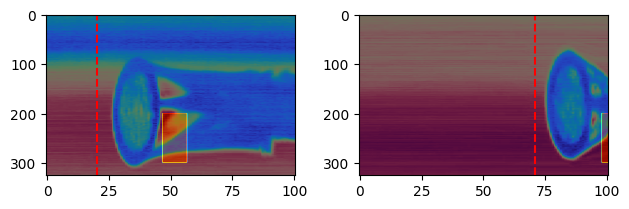

In [23]:
grid_entry_time_first_depth = 20
shift_correction_factor = 1.3
start_shift_pix = int(5e-3 / sampling_time)
length_of_detection = int(2e-3 / sampling_time)
y_bottom_pix = 300
y_top_pix = 200

first_frame = kymographs[depths_to_extract_pix[10]]
last_frame = kymographs[depths_to_extract_pix[-1]]
total_depth_pixels = abs(depths_to_extract_pix[-1] - depths_to_extract_pix[0])
shift_in_frames_total = int(total_depth_pixels * grid_frames_per_pixel_shift * shift_correction_factor)
grid_entry_time_last_depth = grid_entry_time_first_depth + shift_in_frames_total
print(f"Grid entry time for first depth: {grid_entry_time_first_depth}, Last depth: {grid_entry_time_last_depth}")

# get detection mask for first and last frame 
detection_mask_first = np.zeros_like(first_frame, dtype=int)
detection_range_start_first = grid_entry_time_first_depth + start_shift_pix
detection_range_end_first = detection_range_start_first + length_of_detection
detection_mask_first[y_top_pix:y_bottom_pix, detection_range_start_first:detection_range_end_first] = 1

detection_mask_last = np.zeros_like(last_frame, dtype=int)
detection_range_start_last = grid_entry_time_last_depth + start_shift_pix
detection_range_end_last = detection_range_start_last + length_of_detection
detection_mask_last[y_top_pix:y_bottom_pix, detection_range_start_last:detection_range_end_last] = 1
plt.subplot(121)
plt.imshow(first_frame, cmap='turbo', aspect=0.2)
plt.imshow(detection_mask_first, cmap='jet', alpha=0.5, aspect=0.2)
plt.axvline(grid_entry_time_first_depth, color='red', linestyle='--', label='Grid Entry Time First Depth')
plt.subplot(122)
plt.imshow(last_frame, cmap='turbo', aspect=0.2)
plt.imshow(detection_mask_last, cmap='jet', alpha=0.5, aspect=0.2)
plt.axvline(grid_entry_time_last_depth, color='red', linestyle='--', label='Grid Entry Time Last Depth')
plt.tight_layout()
plt.show()


In [30]:
import seaborn as sns
time_points_for_each_depth = {}
for i, depth_point in enumerate(depths_to_extract_pix):
    percentage_progress = (i + 1) / len(depths_to_extract_pix) 
    grid_entry = (depth_point - depths_to_extract_pix[0]) *  shift_correction_factor * grid_frames_per_pixel_shift + grid_entry_time_first_depth
    start_time = int(grid_entry + start_shift_pix)
    end_time = int(start_time + length_of_detection)
    time_points_for_each_depth[depth_point] = {
        "grid_entry": grid_entry,
        "start_time": start_time,
        "end_time": end_time,
        "y_bottom_pix" : y_bottom_pix,
        "y_top_pix" : y_top_pix,
    }
    #print(f"y_top_pix for depth {depth_point} is {time_points_for_each_depth[depth_point]['y_top_pix']}")

velocities_measured = {}
velocities_model = {} 
quality_of_fit = {} 
combined_results = {} 
velocities_model_max = {}
for depth in tqdm(depths_to_extract_pix, desc="Calculating velocities"):
    depth_mm = depths_to_extract[depths_to_extract_pix.index(depth)]  # Convert pixel depth to mm
    kymograph_depth = kymographs[depth]
    velocity_result = get_velocity_from_kymograph(kymograph_depth, \
                                                time_points_for_each_depth[depth], \
                                                apix, sampling_time, epsilon=2, min_points=2)
    velocities_measured[depth_mm] = velocity_result["velocity_m_per_s"]
    velocities_model[depth_mm] = np.sqrt(2 * 9.81 * depth_mm * 1e-3)
    velocities_model_max[depth_mm] = np.sqrt(2 * 9.81 * (depth_mm + 2) * 1e-3)  # Max velocity for the next depth

    quality_of_fit[depth_mm] = velocity_result["r2_fit"]
    combined_results[depth_mm] = velocity_result


Calculating velocities:  11%|█         | 16/146 [00:00<00:00, 151.73it/s]

No points found in the mask and edges intersection.
No points found in the mask and edges intersection.
No points found in the mask and edges intersection.
No points found in the mask and edges intersection.
No points found in the mask and edges intersection.
No points found in the mask and edges intersection.


Calculating velocities:  79%|███████▉  | 116/146 [00:00<00:00, 153.51it/s]

No points found in the mask and edges intersection.
No points found in the mask and edges intersection.
No points found in the mask and edges intersection.
No points found in the mask and edges intersection.
No points found in the mask and edges intersection.
No points found in the mask and edges intersection.
No points found in the mask and edges intersection.
No points found in the mask and edges intersection.
No points found in the mask and edges intersection.
No points found in the mask and edges intersection.
No points found in the mask and edges intersection.
No points found in the mask and edges intersection.
No points found in the mask and edges intersection.
No points found in the mask and edges intersection.
No points found in the mask and edges intersection.
No points found in the mask and edges intersection.
No points found in the mask and edges intersection.
No points found in the mask and edges intersection.


Calculating velocities: 100%|██████████| 146/146 [00:00<00:00, 157.13it/s]


Text(0.5, 1.0, 'Velocity profile')

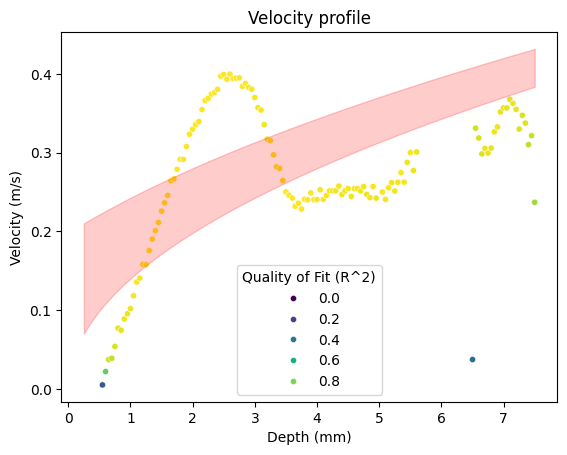

In [33]:
# Plotting the velocities
depths_mm_list = list(depths_to_extract)
velocities_measured_list = [velocities_measured[depth] for depth in depths_mm_list]
velocities_model_list = [velocities_model[depth] for depth in depths_mm_list]
velocities_model_max_list = [velocities_model_max[depth] for depth in depths_mm_list]
quality_of_fit_list = [quality_of_fit[depth] for depth in depths_mm_list]
# color based on quality of fit
results_df = pd.DataFrame({
    "Depth (mm)": depths_mm_list,
    "Measured Velocity (m/s)": velocities_measured_list,
    "Model Velocity (m/s)": velocities_model_list,
    "Model Velocity Max (m/s)": velocities_model_max_list,
    "Quality of Fit (R^2)": quality_of_fit_list
})

sns.scatterplot(data=results_df, x="Depth (mm)", y="Measured Velocity (m/s)", hue="Quality of Fit (R^2)", palette="viridis", s=20)
#sns.lineplot(data=results_df, x="Depth (mm)", y="Model Velocity (m/s)", color='red', label='Model Velocity', linewidth=1)
#sns.lineplot(data=results_df, x="Depth (mm)", y="Model Velocity Max (m/s)", color='orange', label='Model Velocity Max', linewidth=1, linestyle='--')
# show model velocity as with shaded area between model and max model velocity
plt.fill_between(depths_mm_list, velocities_model_list, velocities_model_max_list, color='red', alpha=0.2, label='Model Velocity Range')
#plt.plot(depths_mm_list, velocities_measured_list, marker='o', label='Measured Velocity (m/s)')
#plt.plot(depths_mm_list, velocities_model_list, marker='x', label='Model Velocity (m/s)')
plt.xlabel('Depth (mm)')
plt.ylabel('Velocity (m/s)')
plt.title("Velocity profile")


In [25]:
from ipywidgets import SelectionSlider
step_size = abs(depths_mm_list[1] - depths_mm_list[0])
#depth_to_plot = FloatSlider(depths_mm_list[0], min=depths_mm_list[0], max=depths_mm_list[-1], step=step_size, description='Depth (mm)')
depth_to_plot = SelectionSlider(
    options=depths_mm_list,
    value=depths_mm_list[0],
    description='Depth (mm)',
    continuous_update=True,
    # show only 2 decimal places
    readout_format='.2f',
)
# For each depth plot the kymograph, fitted points, and velocity 
output4 = Output()
def plot_kymograph_at_depth(depth_mm):
    with output4:
        clear_output(wait=True)
        index_depth = depths_mm_list.index(depth_mm)
        depth_pix = depths_to_extract_pix[depths_mm_list.index(depth_mm)]
        kymograph_depth = kymographs[depth_pix]
        velocity_result = combined_results[depth_mm]
        
        plt.figure(figsize=(10, 5))
        plt.imshow(kymograph_depth, cmap='turbo', aspect=0.2)
        plt.plot(velocity_result["x_fit"], velocity_result["y_fit"], color='red', label='Fitted Line')
        plt.scatter(velocity_result["x_points_filtered"], velocity_result["y_points_filtered"], color='blue', s=10, label='Filtered Points')
        plt.axvline(time_points_for_each_depth[depth_pix]["grid_entry"], color='green', linestyle='--', label='Grid Entry Time')
        plt.title(f"Depth: {depth_mm:.2f} mm, Velocity: {velocity_result['velocity_m_per_s']:.2f} m/s, R^2: {velocity_result['r2_fit']:.2f}")
        plt.xlabel('Time (frames)')
        plt.ylabel('Pixel Depth')
        plt.legend()
        plt.colorbar(label='Intensity')
        plt.show()
interact(plot_kymograph_at_depth, depth_mm=depth_to_plot)
display(output4)

interactive(children=(SelectionSlider(description='Depth (mm)', options=(0.1, 0.15000000000000002, 0.200000000…

Output()

In [33]:
# Dump the results into a csv file 
results_basename = os.path.basename(video_path).replace(".mp4", "_velocity_profile_results.csv")
results_path = os.path.join(os.path.dirname(video_path), results_basename)
results_df.to_csv(results_path, index=False)

# Dump all parameters into a csv file
parameters_basename = os.path.basename(video_path).replace(".mp4", "_velocity_profile_parameters.csv")
parameters_path = os.path.join(os.path.dirname(video_path), parameters_basename)
setup_parameters = {
    "apix": apix,
    "frame_rate": int(frame_rate),
    "sampling_time": sampling_time,
    "vplunge": vplunge,
    "kymograph_frame_number_start": int(start_frame_num),
    "kymograph_frame_number_end": int(start_frame_num + length_of_frames.value),
    "depths_to_extract": depths_to_extract.tolist(),
    "depths_to_extract_pix": [int(depth) for depth in depths_to_extract_pix],
    "surface_level": int(surface_level),
    "kymograph_y_start": int(y_1_value),
    "kymograph_y_end": int(y_2_value),
    "grid_entry_time_first_depth": int(grid_entry_time_first_depth),
    "grid_entry_time_last_depth": int(grid_entry_time_last_depth),
}
parameters_df = pd.DataFrame(setup_parameters)
parameters_df.to_csv(parameters_path, index=False)
